In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/robi-datathon-30-qualifier-problem-1/boxes.csv
/kaggle/input/robi-datathon-30-qualifier-problem-1/sample submission 1.csv
/kaggle/input/robi-datathon-30-qualifier-problem-1/problem 1.csv
/kaggle/input/robi-datathon-30-qualifier-problem-1/purchase.csv


In [2]:
!python --version

Python 3.10.13


In [3]:
#warning Ignore
import warnings
warnings.filterwarnings('ignore')

In [4]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import calinski_harabasz_score

In [5]:
import sklearn
print(sklearn.__version__)

1.2.2


In [6]:
#read dataset
boxes=pd.read_csv('/kaggle/input/robi-datathon-30-qualifier-problem-1/boxes.csv')
purchase=pd.read_csv('/kaggle/input/robi-datathon-30-qualifier-problem-1/purchase.csv')

In [7]:
boxes.head()

,BOX_ID,QUALITY,DELIVERY_OPTION,MILK,MEAT,UNIT_PRICE
0,1,Premium,Home Delivery - CoD,0.0,2.7,9.96
1,2,Premium,Home Delivery - CoD,0.0,2.3,11.96
2,3,Premium,Home Delivery - CoD,0.0,2.4,11.96
3,4,Premium,Home Delivery - CoD,0.0,2.5,11.96
4,5,Premium,Home Delivery - CoD,0.0,2.6,11.96


In [8]:
boxes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290 entries, 0 to 289
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   BOX_ID           290 non-null    int64  
 1   QUALITY          290 non-null    object 
 2   DELIVERY_OPTION  290 non-null    object 
 3   MILK             290 non-null    float64
 4   MEAT             290 non-null    float64
 5   UNIT_PRICE       290 non-null    float64
dtypes: float64(3), int64(1), object(2)
memory usage: 13.7+ KB


In [9]:
boxes.duplicated().sum()

0

In [10]:
#Unique BOX_ID
boxes['BOX_ID'].nunique()

290

In [11]:
boxes.isna().sum()

BOX_ID             0
QUALITY            0
DELIVERY_OPTION    0
MILK               0
MEAT               0
UNIT_PRICE         0
dtype: int64

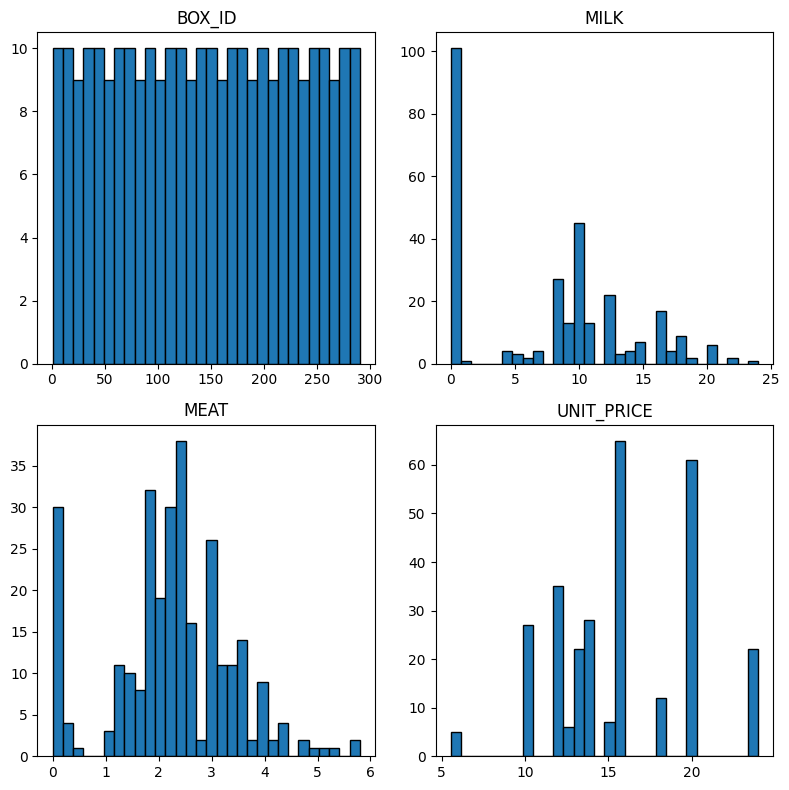

In [12]:
#Histplot
fig,axes=plt.subplots(2,2,figsize=(8,8))
axes=axes.flatten()

numCol=boxes.select_dtypes(include=np.number)
for i, each in enumerate(numCol):
    axes[i].hist(boxes[each], bins=30, edgecolor='black')
    axes[i].set_title(each)

plt.tight_layout()
plt.show()

In [13]:
purchase.head()

,PURCHASE_DATE,MAGIC_KEY,BOX_ID,BOX_COUNT
0,1/2/2019,2CED678A247,12.0,1.0
1,1/2/2019,2BF58D91BA1,12.0,1.0
2,1/2/2019,2C15B86534E,99.0,1.0
3,1/2/2019,2C32D9A859A,6.0,1.0
4,1/2/2019,2C7A55404D1,4.0,1.0


In [14]:
purchase.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2455864 entries, 0 to 2455863
Data columns (total 4 columns):
 #   Column         Dtype  
---  ------         -----  
 0   PURCHASE_DATE  object 
 1   MAGIC_KEY      object 
 2   BOX_ID         float64
 3   BOX_COUNT      float64
dtypes: float64(2), object(2)
memory usage: 74.9+ MB


In [15]:
#unique BOX_COUNT
purchase['BOX_COUNT'].unique()

array([ 1., nan, -1.,  2.,  4.,  3.,  8.,  6.,  5.,  7.,  9., 19., 10.,
       11., 13.])

In [16]:
purchase[purchase['BOX_COUNT']!=1]

,PURCHASE_DATE,MAGIC_KEY,BOX_ID,BOX_COUNT
177,1/2/2019,28FF265F082,NaN,NaN
178,1/2/2019,2CB168CDFA3,NaN,NaN
179,1/2/2019,2C2C8844F09,NaN,NaN
180,1/2/2019,2BDCCEF05A4,NaN,NaN
181,1/2/2019,2BF1D98D0B2,NaN,NaN
...,...,...,...,...
2447978,30/10/2018,2CEAADCC0E3,89.0,2.0
2448163,30/10/2018,290473E1446,258.0,2.0
2450319,29/10/2018,2BF22F3577E,89.0,2.0
2451380,30/10/2018,290C0091CAB,258.0,2.0


In [17]:
purchase.duplicated().sum()

77

In [18]:
purchase.drop_duplicates(inplace=True)

In [19]:
purchase.duplicated().sum()

0

In [20]:
purchase.isna().sum()

PURCHASE_DATE     0
MAGIC_KEY         0
BOX_ID           47
BOX_COUNT        47
dtype: int64

In [21]:
purchase.dropna(inplace=True)

In [22]:
purchase.isna().sum()

PURCHASE_DATE    0
MAGIC_KEY        0
BOX_ID           0
BOX_COUNT        0
dtype: int64

In [23]:
purchase[(purchase['BOX_COUNT']<=0) | (purchase['BOX_ID']<=0)]

,PURCHASE_DATE,MAGIC_KEY,BOX_ID,BOX_COUNT
191,1/2/2019,2CCB122460D,11111111.0,-1.0
192,1/2/2019,2CEDA71E3E9,11111111.0,-1.0
193,1/2/2019,2CBDC970258,11111111.0,-1.0
194,1/2/2019,2932761FEB6,11111111.0,-1.0
195,1/2/2019,28F09714410,11111111.0,-1.0
196,1/2/2019,2BDAE37A00E,11111111.0,-1.0
197,1/2/2019,2C3C7E168F7,11111111.0,-1.0
525713,27/2/2019,2C3C7E168F7,11111111.0,-1.0
597615,1/1/2019,2CEDA71E3E9,11111111.0,-1.0
665861,5/1/2019,2C3C7E168F7,11111111.0,-1.0


In [24]:
garbage=purchase[(purchase['BOX_COUNT']<=0) | (purchase['BOX_ID']<=0)]

In [25]:
purchase.drop(garbage.index, axis=0, inplace=True)

In [26]:
purchase.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2455723 entries, 0 to 2455863
Data columns (total 4 columns):
 #   Column         Dtype  
---  ------         -----  
 0   PURCHASE_DATE  object 
 1   MAGIC_KEY      object 
 2   BOX_ID         float64
 3   BOX_COUNT      float64
dtypes: float64(2), object(2)
memory usage: 93.7+ MB


In [27]:
purchase['BOX_COUNT'].value_counts()

BOX_COUNT
1.0     2453301
2.0        2272
3.0          83
4.0          28
6.0          17
5.0          10
7.0           3
9.0           2
19.0          2
11.0          2
8.0           1
10.0          1
13.0          1
Name: count, dtype: int64

In [28]:
merged=pd.merge(purchase, boxes, on='BOX_ID', how='left')

In [29]:
merged.tail()

,PURCHASE_DATE,MAGIC_KEY,BOX_ID,BOX_COUNT,QUALITY,DELIVERY_OPTION,MILK,MEAT,UNIT_PRICE
2455718,28/10/2018,2BD992B5538,12.0,1.0,Premium,Home Delivery - CoD,8.0,1.5,12.98
2455719,28/10/2018,2C97CD72233,17.0,1.0,Premium,Home Delivery - CoD,10.0,1.8,12.98
2455720,28/10/2018,2C91C61D372,40.0,1.0,Premium,Home Delivery - CoD,12.0,1.8,19.98
2455721,28/10/2018,2CD70CFC4E3,51.0,1.0,Premium,Home Delivery - CoD,18.0,2.9,23.98
2455722,28/10/2018,2C4792A5B84,4.0,1.0,Premium,Home Delivery - CoD,0.0,2.5,11.96


In [30]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2455723 entries, 0 to 2455722
Data columns (total 9 columns):
 #   Column           Dtype  
---  ------           -----  
 0   PURCHASE_DATE    object 
 1   MAGIC_KEY        object 
 2   BOX_ID           float64
 3   BOX_COUNT        float64
 4   QUALITY          object 
 5   DELIVERY_OPTION  object 
 6   MILK             float64
 7   MEAT             float64
 8   UNIT_PRICE       float64
dtypes: float64(5), object(4)
memory usage: 168.6+ MB


In [31]:
#format specify in which sequence day,month,year have stored in object datatype
merged['PURCHASE_DATE']=pd.to_datetime(merged['PURCHASE_DATE'],format='%d/%m/%Y')

In [32]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2455723 entries, 0 to 2455722
Data columns (total 9 columns):
 #   Column           Dtype         
---  ------           -----         
 0   PURCHASE_DATE    datetime64[ns]
 1   MAGIC_KEY        object        
 2   BOX_ID           float64       
 3   BOX_COUNT        float64       
 4   QUALITY          object        
 5   DELIVERY_OPTION  object        
 6   MILK             float64       
 7   MEAT             float64       
 8   UNIT_PRICE       float64       
dtypes: datetime64[ns](1), float64(5), object(3)
memory usage: 168.6+ MB


In [33]:
merged['PURCHASE_DATE'].min(), merged['PURCHASE_DATE'].max()

(Timestamp('2018-10-01 00:00:00'), Timestamp('2019-02-28 00:00:00'))

In [34]:
merged['MAGIC_KEY'].value_counts()

MAGIC_KEY
2CC2011C2DF    40
28D251217BD    38
2BFCB915234    36
29D9005EBAD    35
29F30296E7B    34
               ..
2C9CC96DD72     1
2CC8A824B5A     1
2C061F5E97B     1
2BC4A1CD79F     1
2C4792A5B84     1
Name: count, Length: 1274087, dtype: int64

In [35]:
merged['dayGapBetweenTwoPurchase']=merged.sort_values(['MAGIC_KEY','PURCHASE_DATE']).groupby('MAGIC_KEY')['PURCHASE_DATE'].diff().dt.days

In [36]:
merged.isna().sum()

PURCHASE_DATE                     0
MAGIC_KEY                         0
BOX_ID                            0
BOX_COUNT                         0
QUALITY                           0
DELIVERY_OPTION                   0
MILK                              0
MEAT                              0
UNIT_PRICE                        0
dayGapBetweenTwoPurchase    1274087
dtype: int64

Text(0, 0.5, 'Count')

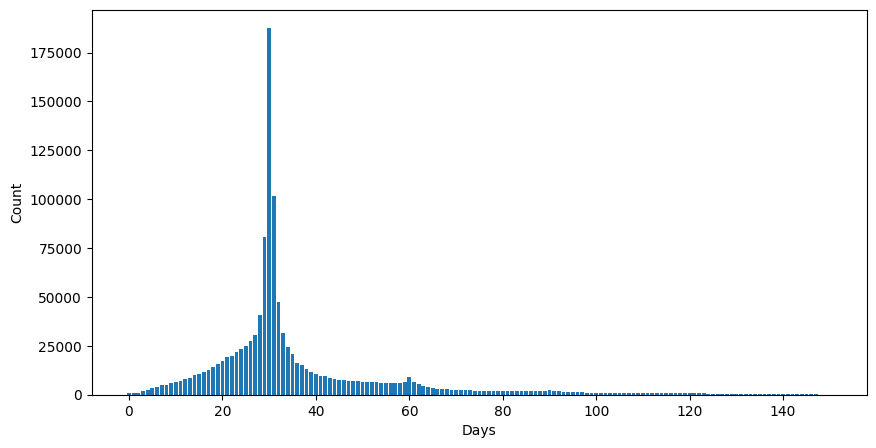

In [37]:
#barplot of merged['minDate-currentDate'].value_counts()
plt.figure(figsize=(10,5))
plt.bar(merged['dayGapBetweenTwoPurchase'].value_counts().index,
       merged['dayGapBetweenTwoPurchase'].value_counts().values)
plt.xlabel('Days')
plt.ylabel('Count')

# Sales Analysis

In [38]:
limit1=pd.to_datetime('31/10/18',format='%d/%m/%y')
limit2=pd.to_datetime('30/11/18',format='%d/%m/%y')
limit3=pd.to_datetime('31/12/18',format='%d/%m/%y')
limit4=pd.to_datetime('31/1/19',format='%d/%m/%y')

def monthFromDate(val):
    if (val<=limit1):
        return 'October'
    elif (limit1<val<=limit2):
        return 'November'
    elif (limit2<val<=limit3):
        return 'December'
    elif (limit3<val<=limit4):
        return 'January'
    else:
        return 'February'

merged['Month']=merged['PURCHASE_DATE'].apply(monthFromDate)

In [39]:
merged.head()

,PURCHASE_DATE,MAGIC_KEY,BOX_ID,BOX_COUNT,QUALITY,DELIVERY_OPTION,MILK,MEAT,UNIT_PRICE,dayGapBetweenTwoPurchase,Month
0,2019-02-01,2CED678A247,12.0,1.0,Premium,Home Delivery - CoD,8.0,1.5,12.98,NaN,February
1,2019-02-01,2BF58D91BA1,12.0,1.0,Premium,Home Delivery - CoD,8.0,1.5,12.98,NaN,February
2,2019-02-01,2C15B86534E,99.0,1.0,Premium,Delivery from Collection Point,0.0,3.3,13.96,43.0,February
3,2019-02-01,2C32D9A859A,6.0,1.0,Premium,Home Delivery - CoD,0.0,2.7,11.96,NaN,February
4,2019-02-01,2C7A55404D1,4.0,1.0,Premium,Home Delivery - CoD,0.0,2.5,11.96,NaN,February


In [40]:
month=['October','November','December','January','February']
for i, each in enumerate(month):
    temp=merged[merged['Month']==each]
    newCus=temp['dayGapBetweenTwoPurchase'].isna().sum()
    returnCusData=temp.dropna(subset=['dayGapBetweenTwoPurchase'])
    uniqueReturnCus=returnCusData['MAGIC_KEY'].nunique()
    print(f'newCus={newCus}, uniqueReturnCus={uniqueReturnCus}, returnCus={returnCusData.shape[0]}')

newCus=417228, uniqueReturnCus=25713, returnCus=28250
newCus=225625, uniqueReturnCus=186017, returnCus=203666
newCus=200124, uniqueReturnCus=243452, returnCus=265805
newCus=205959, uniqueReturnCus=293522, returnCus=321249
newCus=225151, uniqueReturnCus=339248, returnCus=362666


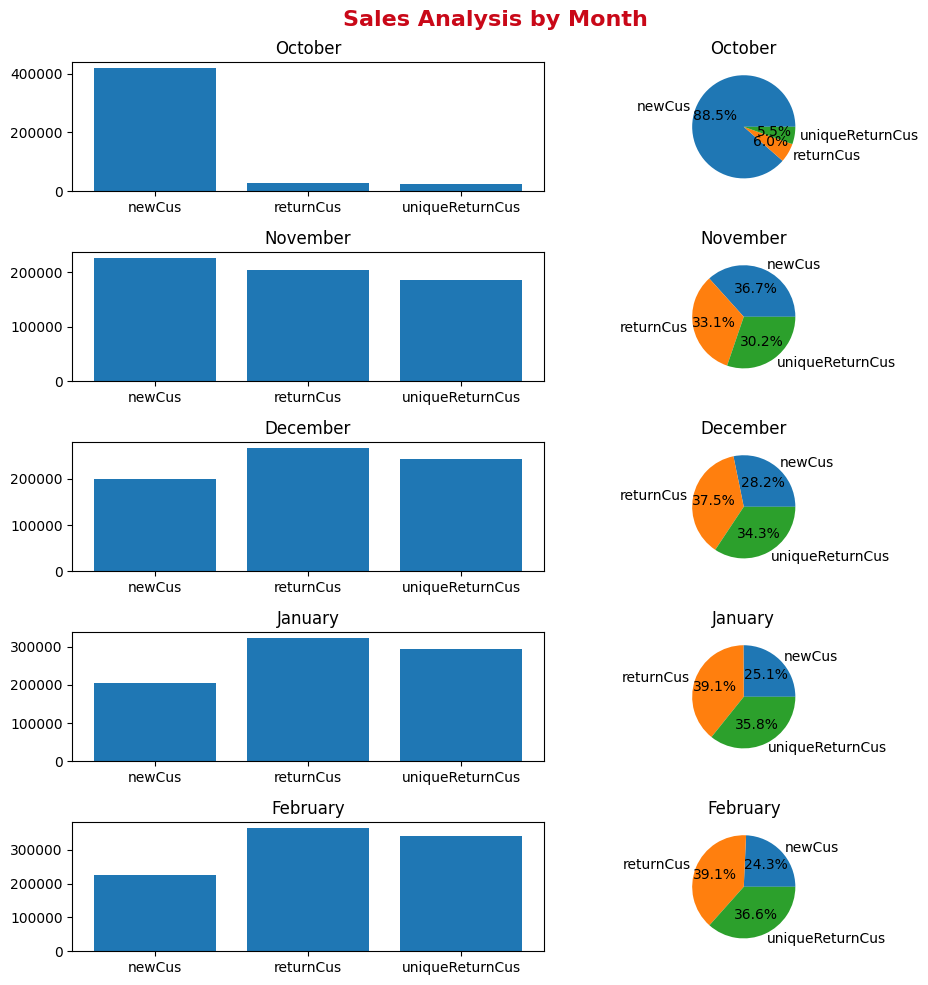

In [41]:
fig, axes=plt.subplots(5,2, figsize=(10,10))
axes=axes.flatten()

month=['October','November','December','January','February']
for i, each in enumerate(month):
    temp=merged[merged['Month']==each]
    newCus=temp['dayGapBetweenTwoPurchase'].isna().sum()
    returnCusData=temp.dropna(subset=['dayGapBetweenTwoPurchase'])
    uniqueReturnCus=returnCusData['MAGIC_KEY'].nunique()
    #barplot
    axes[2*i].bar(['newCus', 'returnCus', 'uniqueReturnCus'], 
                  [newCus, returnCusData.shape[0], uniqueReturnCus])
    axes[2*i].set_title(each)
    #pieplot
    axes[2*i+1].pie([newCus, returnCusData.shape[0], uniqueReturnCus], 
                    labels=['newCus', 'returnCus', 'uniqueReturnCus'], 
                    autopct='%1.1f%%')
    axes[2*i+1].set_title(each)

fig.suptitle("Sales Analysis by Month", fontsize=16, c='#c90818', fontweight='bold')
plt.tight_layout()
plt.show()

From the plots above, we can see that the number of returning customers has been increasing steadily each month. In the past year, the total number of returning customers exceeded 300,000. Based on this trend, we can reasonably expect that around 150,000 returning customers will make purchases within the first 15 days of the next month.

In [42]:
uniqueCustomer=pd.DataFrame(data=merged['MAGIC_KEY'].value_counts())
uniqueCustomer.columns=['visitCount']
uniqueCustomer.head()

,visitCount
MAGIC_KEY,
2CC2011C2DF,40
28D251217BD,38
2BFCB915234,36
29D9005EBAD,35
29F30296E7B,34


In [43]:
uniqueCustomer.shape

(1274087, 1)

In [44]:
uniqueCustomer['gapVisit(median)']=merged.groupby('MAGIC_KEY')['dayGapBetweenTwoPurchase'].median()

In [45]:
uniqueCustomer.head()

,visitCount,gapVisit(median)
MAGIC_KEY,,
2CC2011C2DF,40,2.0
28D251217BD,38,2.0
2BFCB915234,36,3.0
29D9005EBAD,35,4.0
29F30296E7B,34,2.0


In [46]:
uniqueCustomer[uniqueCustomer['visitCount']==1]

,visitCount,gapVisit(median)
MAGIC_KEY,,
29142EA7D8C,1,NaN
29069E085E9,1,NaN
29099076111,1,NaN
2C8D4EBDEAD,1,NaN
2C185BB0898,1,NaN
...,...,...
2C9CC96DD72,1,NaN
2CC8A824B5A,1,NaN
2C061F5E97B,1,NaN


In [47]:
uniqueCustomer.isna().sum()

visitCount               0
gapVisit(median)    719542
dtype: int64

In [48]:
#Whose visitCount=1, these gapVisit(median)=null. So, we can drop these
mulVisitCus=uniqueCustomer.dropna()#multipleVisitCustomer
mulVisitCus.isna().sum()

visitCount          0
gapVisit(median)    0
dtype: int64

In [49]:
mulVisitCus[mulVisitCus['gapVisit(median)']==0].head()

,visitCount,gapVisit(median)
MAGIC_KEY,,
2C4FDB5ED31,17,0.0
2C3ECE53EE6,7,0.0
2CF43A0EFA0,6,0.0
28EF1BDA08B,5,0.0
295EA193564,4,0.0


In [50]:
merged[merged['MAGIC_KEY']=='2C4FDB5ED31'].sort_values('PURCHASE_DATE')

,PURCHASE_DATE,MAGIC_KEY,BOX_ID,BOX_COUNT,QUALITY,DELIVERY_OPTION,MILK,MEAT,UNIT_PRICE,dayGapBetweenTwoPurchase,Month
2281786,2018-10-15,2C4FDB5ED31,134.0,1.0,Premium,Delivery from Collection Point,10.0,1.8,19.98,0.0,October
2281769,2018-10-15,2C4FDB5ED31,165.0,1.0,Premium,Delivery from Collection Point,12.0,2.5,23.98,NaN,October
2281773,2018-10-15,2C4FDB5ED31,27.0,2.0,Premium,Home Delivery - CoD,0.0,2.9,15.96,0.0,October
1235334,2018-12-09,2C4FDB5ED31,134.0,1.0,Premium,Delivery from Collection Point,10.0,1.8,19.98,0.0,December
1235329,2018-12-09,2C4FDB5ED31,106.0,1.0,Premium,Delivery from Collection Point,0.0,3.3,15.96,55.0,December
1477251,2018-12-19,2C4FDB5ED31,174.0,1.0,Premium,Delivery from Collection Point,18.0,2.9,23.98,10.0,December
1432157,2018-12-25,2C4FDB5ED31,193.0,1.0,Premium,Home Delivery - Digital Payment,14.0,2.0,19.98,0.0,December
1390827,2018-12-25,2C4FDB5ED31,134.0,1.0,Premium,Delivery from Collection Point,10.0,1.8,19.98,6.0,December
279006,2019-02-15,2C4FDB5ED31,179.0,1.0,Premium,Home Delivery - Digital Payment,0.0,2.4,13.96,52.0,February
282114,2019-02-15,2C4FDB5ED31,187.0,1.0,Premium,Home Delivery - Digital Payment,9.0,1.6,15.98,0.0,February


Text(0, 0.5, 'Frequency')

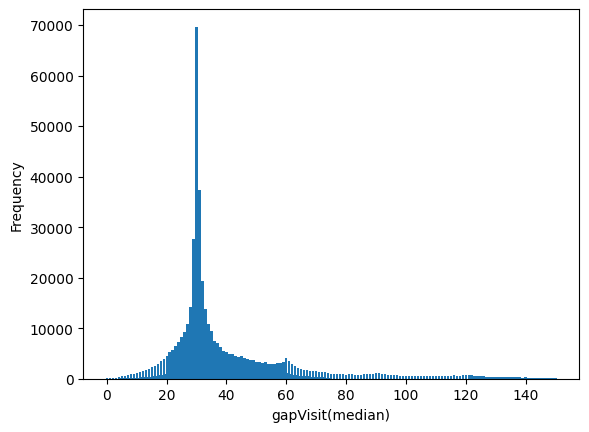

In [51]:
#Barplot of meanInterval without '0'
temp=mulVisitCus['gapVisit(median)'].value_counts()
plt.bar(temp.index, temp.values)
plt.xlabel('gapVisit(median)')
plt.ylabel('Frequency')

In [52]:
mulVisitCus.shape

(554545, 2)

<Axes: xlabel='gapVisit(median)', ylabel='visitCount'>

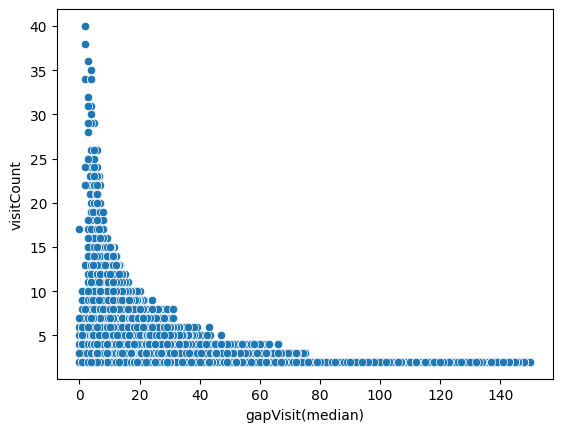

In [53]:
#scatterPlot of meanInterval & visitCount
sns.scatterplot(data=mulVisitCus, x='gapVisit(median)',y='visitCount')

In [54]:
mulVisitCus.head()

,visitCount,gapVisit(median)
MAGIC_KEY,,
2CC2011C2DF,40,2.0
28D251217BD,38,2.0
2BFCB915234,36,3.0
29D9005EBAD,35,4.0
29F30296E7B,34,2.0


In [55]:
# calculate NumberOfPurchaseDay, PurchasableDay
lastDate=merged['PURCHASE_DATE'].max()
temp=merged.groupby('MAGIC_KEY').agg(
    NumberOfPurchaseDay=('PURCHASE_DATE','nunique'),
    FirstPurchase=('PURCHASE_DATE','min'))

#(4/1/2019-1/1/2019)=3, but PurchasableDay should be 4 
#1/1/19, 2/1/19, 3/1/19, 4/1/19
temp['PurchasableDay']=(lastDate-temp['FirstPurchase']).dt.days+1
temp.drop('FirstPurchase',axis=1,inplace=True)
temp.head()

,NumberOfPurchaseDay,PurchasableDay
MAGIC_KEY,,
249670911D8,2,120
249751FC4DD,1,140
24978027606,1,133
24979164422,1,91
2497B8B4FDA,2,149


In [56]:
mulVisitCus=mulVisitCus.join(temp)

In [57]:
mulVisitCus.head()

,visitCount,gapVisit(median),NumberOfPurchaseDay,PurchasableDay
MAGIC_KEY,,,,
2CC2011C2DF,40,2.0,40,142
28D251217BD,38,2.0,38,96
2BFCB915234,36,3.0,36,147
29D9005EBAD,35,4.0,35,147
29F30296E7B,34,2.0,34,58


In [58]:
mulVisitCus[mulVisitCus['visitCount']> mulVisitCus['NumberOfPurchaseDay']]

,visitCount,gapVisit(median),NumberOfPurchaseDay,PurchasableDay
MAGIC_KEY,,,,
290ECCA4FE0,28,3.0,27,149
2C09B1A16BF,22,6.0,21,141
28DBBCC800C,20,7.0,19,139
29839FB6BE6,18,7.0,17,147
2C32C19199B,18,6.0,17,116
...,...,...,...,...
2CBC4EE4281,2,0.0,1,6
28FA6D94687,2,0.0,1,119
2C52078273A,2,0.0,1,28


In [59]:
mulVisitCus['NumberOfPurchaseDay/PurchasableDay']=mulVisitCus['NumberOfPurchaseDay']/mulVisitCus['PurchasableDay']

In [60]:
mulVisitCus.head()

,visitCount,gapVisit(median),NumberOfPurchaseDay,PurchasableDay,NumberOfPurchaseDay/PurchasableDay
MAGIC_KEY,,,,,
2CC2011C2DF,40,2.0,40,142,0.281690
28D251217BD,38,2.0,38,96,0.395833
2BFCB915234,36,3.0,36,147,0.244898
29D9005EBAD,35,4.0,35,147,0.238095
29F30296E7B,34,2.0,34,58,0.586207


In [61]:
#filter
mulVisitCus[
    (mulVisitCus['NumberOfPurchaseDay/PurchasableDay']<=0.1) & 
    (mulVisitCus['NumberOfPurchaseDay']>=10) & 
    (mulVisitCus['gapVisit(median)']<=15)]

,visitCount,gapVisit(median),NumberOfPurchaseDay,PurchasableDay,NumberOfPurchaseDay/PurchasableDay
MAGIC_KEY,,,,,
292B9183D36,15,8.0,14,148,0.094595
28FAA7FAE60,15,9.0,15,151,0.099338
290E22201E8,15,8.0,15,151,0.099338
2C4489467D3,15,11.5,15,150,0.100000
2BC9FF6C923,15,9.0,14,146,0.095890
...,...,...,...,...,...
28D99442C4F,10,11.0,10,140,0.071429
2BF59B8EE28,10,9.0,10,107,0.093458
2C7E6AE76E9,10,12.0,10,134,0.074627


In [62]:
#filter
mulVisitCus[
    (mulVisitCus['NumberOfPurchaseDay/PurchasableDay']>=0.1) & 
    (mulVisitCus['NumberOfPurchaseDay']>=10) & 
    (mulVisitCus['gapVisit(median)']<=15)]

,visitCount,gapVisit(median),NumberOfPurchaseDay,PurchasableDay,NumberOfPurchaseDay/PurchasableDay
MAGIC_KEY,,,,,
2CC2011C2DF,40,2.0,40,142,0.281690
28D251217BD,38,2.0,38,96,0.395833
2BFCB915234,36,3.0,36,147,0.244898
29D9005EBAD,35,4.0,35,147,0.238095
29F30296E7B,34,2.0,34,58,0.586207
...,...,...,...,...,...
28F896CDE51,10,3.0,10,29,0.344828
2966C58A9B3,10,4.0,10,67,0.149254
297E1BF7EFE,10,6.0,10,77,0.129870


In [63]:
#filter
mulVisitCus[
    (mulVisitCus['NumberOfPurchaseDay']>=10) & 
    (mulVisitCus['gapVisit(median)']<=15)]

,visitCount,gapVisit(median),NumberOfPurchaseDay,PurchasableDay,NumberOfPurchaseDay/PurchasableDay
MAGIC_KEY,,,,,
2CC2011C2DF,40,2.0,40,142,0.281690
28D251217BD,38,2.0,38,96,0.395833
2BFCB915234,36,3.0,36,147,0.244898
29D9005EBAD,35,4.0,35,147,0.238095
29F30296E7B,34,2.0,34,58,0.586207
...,...,...,...,...,...
28D99442C4F,10,11.0,10,140,0.071429
2BF59B8EE28,10,9.0,10,107,0.093458
2C7E6AE76E9,10,12.0,10,134,0.074627


<Axes: xlabel='visitCount', ylabel='gapVisit(median)'>

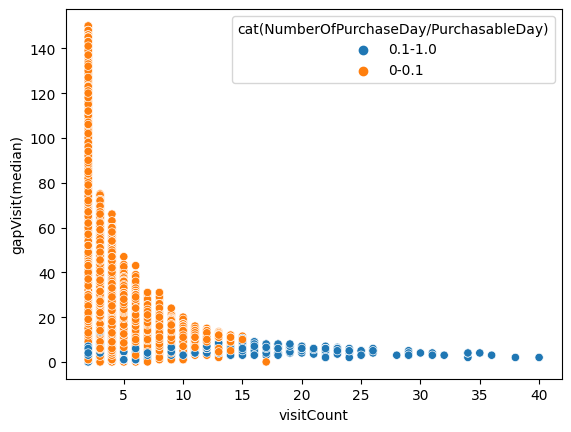

In [64]:
#categorizer 
def catSelector(val):
    if (0<val<=0.1):
        return '0-0.1'
    else:
        return '0.1-1.0'

#apply categorizer
mulVisitCus['cat(NumberOfPurchaseDay/PurchasableDay)']=mulVisitCus['NumberOfPurchaseDay/PurchasableDay'].apply(catSelector)

#scatterplot
sns.scatterplot(data=mulVisitCus,
                x='visitCount', 
                y='gapVisit(median)',
                hue='cat(NumberOfPurchaseDay/PurchasableDay)')

<Axes: xlabel='visitCount', ylabel='gapVisit(median)'>

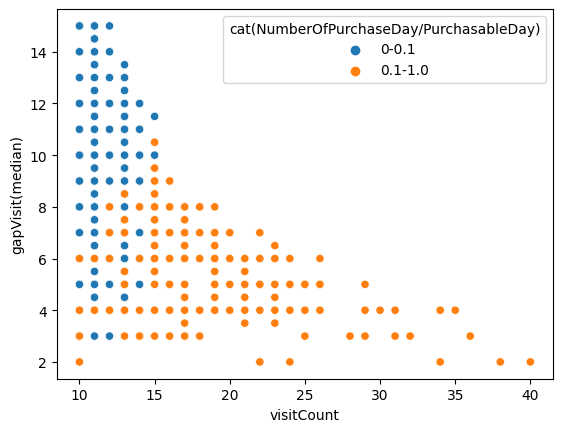

In [65]:
#filter
temp=mulVisitCus[
    (mulVisitCus['NumberOfPurchaseDay']>=10) & 
    (mulVisitCus['gapVisit(median)']<=15)]

#scatterplot
hue_order=['0-0.1','0.1-1.0']
sns.scatterplot(data=temp,
                x='visitCount', 
                y='gapVisit(median)',
                hue='cat(NumberOfPurchaseDay/PurchasableDay)',
                hue_order=hue_order)

In [66]:
mulVisitCus.head()

,visitCount,gapVisit(median),NumberOfPurchaseDay,PurchasableDay,NumberOfPurchaseDay/PurchasableDay,cat(NumberOfPurchaseDay/PurchasableDay)
MAGIC_KEY,,,,,,
2CC2011C2DF,40,2.0,40,142,0.281690,0.1-1.0
28D251217BD,38,2.0,38,96,0.395833,0.1-1.0
2BFCB915234,36,3.0,36,147,0.244898,0.1-1.0
29D9005EBAD,35,4.0,35,147,0.238095,0.1-1.0
29F30296E7B,34,2.0,34,58,0.586207,0.1-1.0


**Use K-Means Clustering**

In [67]:
readyToCluster=mulVisitCus.drop(columns=['PurchasableDay','cat(NumberOfPurchaseDay/PurchasableDay)'],
                               axis=1)
readyToCluster.head()

,visitCount,gapVisit(median),NumberOfPurchaseDay,NumberOfPurchaseDay/PurchasableDay
MAGIC_KEY,,,,
2CC2011C2DF,40,2.0,40,0.281690
28D251217BD,38,2.0,38,0.395833
2BFCB915234,36,3.0,36,0.244898
29D9005EBAD,35,4.0,35,0.238095
29F30296E7B,34,2.0,34,0.586207


**Elbow Method**

In [68]:
#from sklearn.preprocessing import MinMaxScaler
mms=MinMaxScaler()
temp=mms.fit_transform(readyToCluster)
scaledData=pd.DataFrame(temp, 
                        columns=readyToCluster.columns, 
                        index=readyToCluster.index)
scaledData.head()

,visitCount,gapVisit(median),NumberOfPurchaseDay,NumberOfPurchaseDay/PurchasableDay
MAGIC_KEY,,,,
2CC2011C2DF,1.000000,0.013333,1.000000,0.276869
28D251217BD,0.947368,0.013333,0.948718,0.391779
2BFCB915234,0.894737,0.020000,0.897436,0.239830
29D9005EBAD,0.868421,0.026667,0.871795,0.232982
29F30296E7B,0.842105,0.013333,0.846154,0.583430


Text(0, 0.5, 'Value of Inertia')

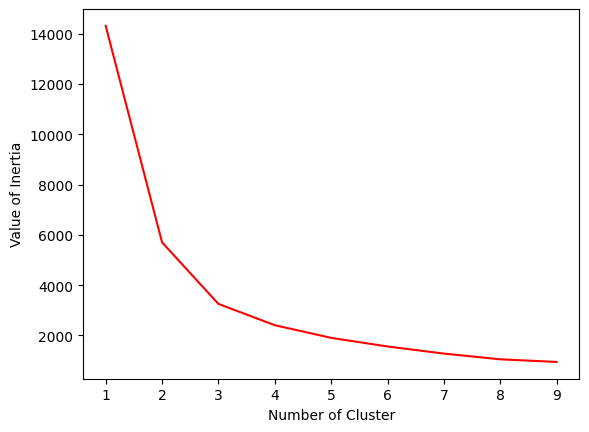

In [69]:
#find Inertia
#Inertia means sum of squared distances of samples to their closest cluster center
inertias=[]
for k in range(1,10):
    km=KMeans(n_clusters=k,random_state=42)
    km.fit_predict(scaledData)
    inertias.append(km.inertia_)

#plot Inertia
plt.plot(range(1,10),inertias,c='r')
plt.xlabel('Number of Cluster')
plt.ylabel('Value of Inertia')

 # Silhouette Metric<br>
 The silhouette score is a metric used to evaluate the quality of clustering algorithms by measuring how well each data point fits into its assigned cluster compared to others, ranging from -1 to 1. A score near 1 indicates well-separated & distinct clusters, 0 indicates overlapping clusters, and -1 indicates misclassified points. It is calculated using the mean intra-cluster distance (a) and the mean nearest-cluster distance (b).<br>
  * **Formula**: $$ s=\frac{(b-a)}{max(a,b)} $$
    
  * **Interpretation**:
    * +1: Data point is far away from neighboring clusters (good).
    * 0: Data point is on the boundary between two clusters.
    * -1: Data point is likely assigned to the wrong cluster.

  * **Purpose**: It validates clustering performance and helps determine the optimal number of clusters.
    

Execution time = 69.808509349823 sec


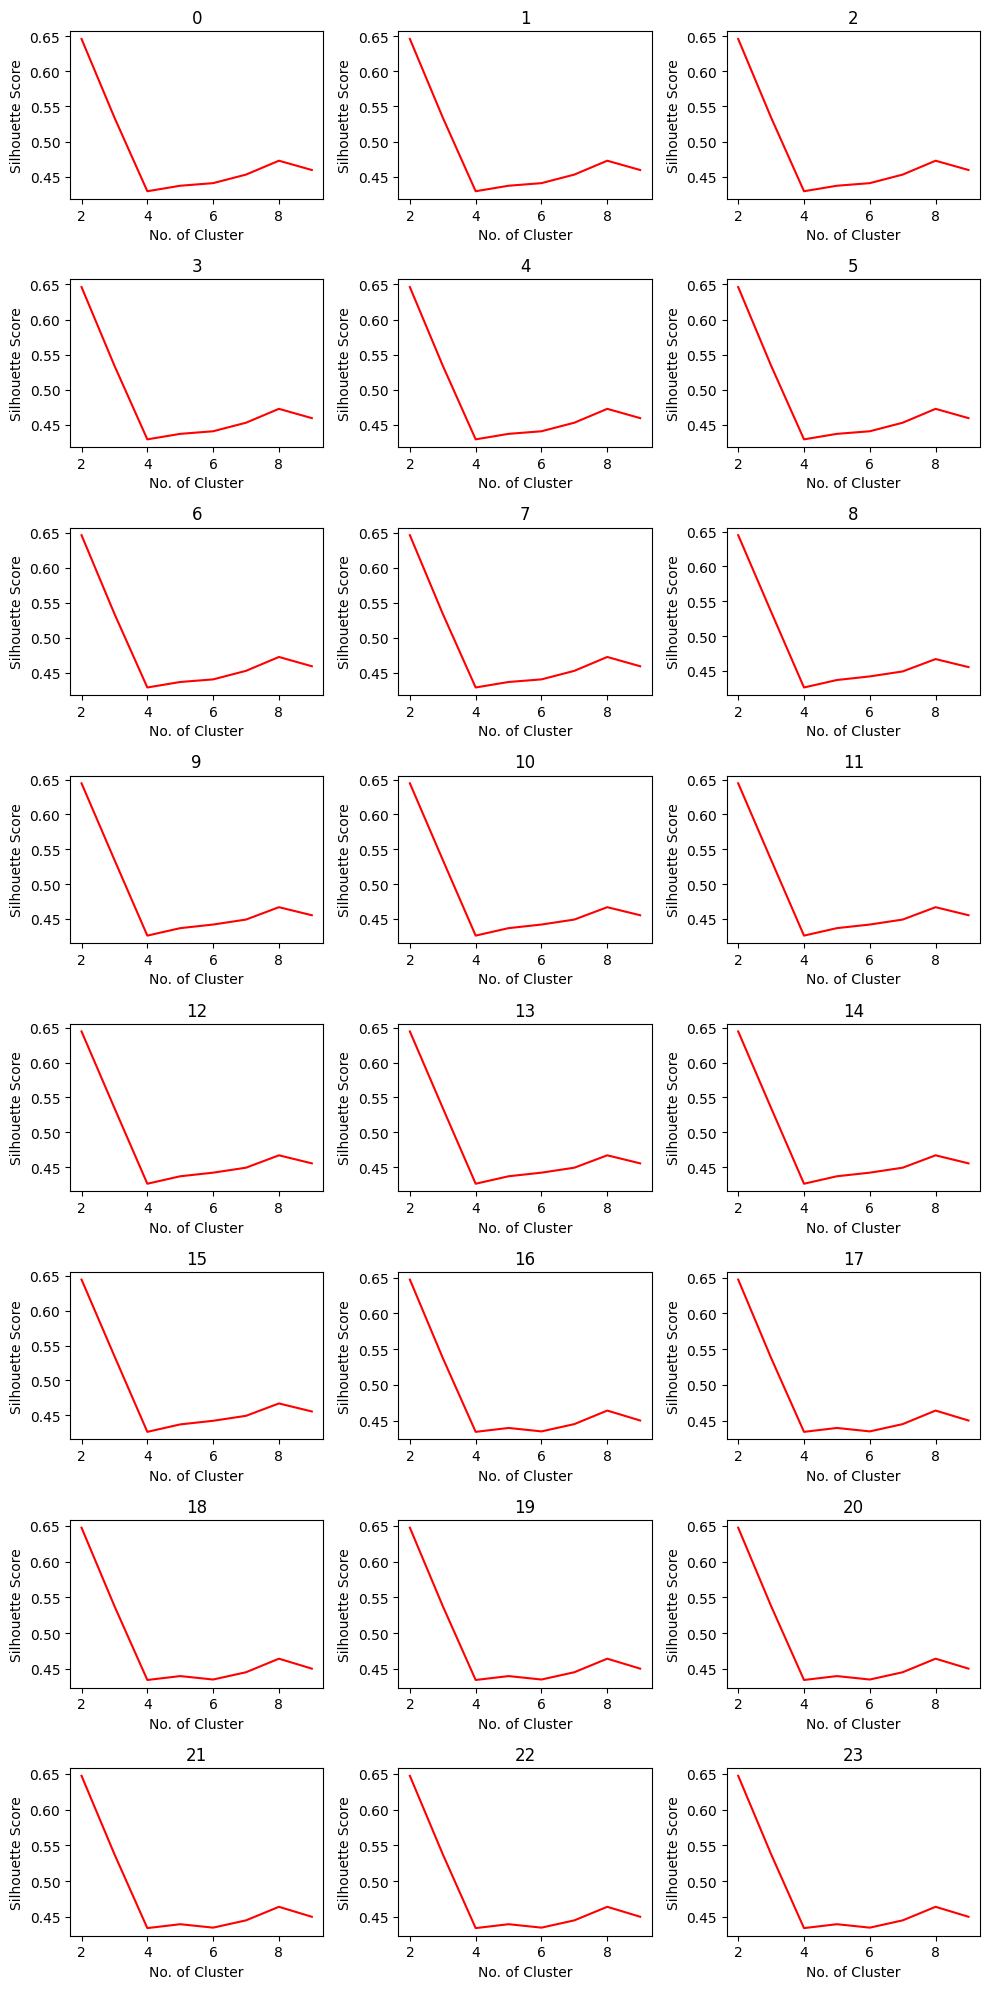

In [70]:
#Find silhouette score and plot for random 10000 row 
#from sklearn.metrics import silhouette_score

silScorePerSample=[]
start=time.time()
for each in range(0,3):
    #subset for silhouette_score. since, dataset is big silhouette_score take huge time to execute
    sampleIndex=np.random.choice(len(scaledData), size=10000,replace=False)
    silScores=[]
    for k in range(2,10): # silhouette needs at least 2 clusters, silhouette score is undefined for k=1
        km=KMeans(n_clusters=k,random_state=42)
        clusterLabels=km.fit_predict(scaledData)
        silScores.append(silhouette_score(scaledData.iloc[sampleIndex], clusterLabels[sampleIndex]))
        silScorePerSample.append(silScores)
end=time.time()
print(f"Execution time = {end-start} sec")
#Plot
fig,axes=plt.subplots(8,3,figsize=(10,20))
axes=axes.flatten()
for i,each in enumerate(silScorePerSample):
    axes[i].plot(range(2,10), each, c='r')
    axes[i].set_xlabel('No. of Cluster')
    axes[i].set_ylabel('Silhouette Score')
    axes[i].set_title(i)

plt.tight_layout()
plt.show()
    

# Calinski-Harabasz Score
The **Calinski-Harabasz (CH)** index, also known as the Variance Ratio Criterion, is an internal evaluation metric used in machine learning to assess the quality of clustering algorithms. It measures the ratio of the sum of between-clusters dispersion to the within-cluster dispersion.

* **Formula Components:**
  1. **Between-Cluster Dispersion (BCSS)**: Measures how far apart the clusters are from the global center.
  2. **Within-Cluster Dispersion (WCSS)**: Measures how close data points are to their own cluster center.
     
* **Formula**: $$ CH=\frac{BCSS/(k-1)}{WCSS/(n-k)} $$   where, **n** = number of data points & **k** = number of clusters

* **Interpretation**:

   * **Higher CH Score → Better clustering.** Clusters are compact (low WCSS) and well-separated (high BCSS).
   * **Lower CH Score → Poor clustering.** - Clusters overlap or are loosely defined.


Text(0.5, 1.0, 'Calinski-Harabasz(CH)')

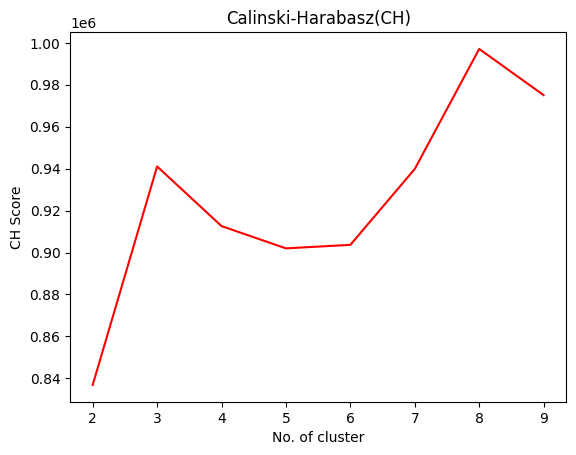

In [71]:
#from sklearn.metrics import calinski_harabasz_score
#calculate CH scores
chScores=[]
for each in range(2,10):
    km=KMeans(n_clusters=each,random_state=42)
    clusterLabels=km.fit_predict(scaledData)
    chScores.append(calinski_harabasz_score(scaledData, clusterLabels))

#plot 
plt.plot(range(2,10),chScores, c='r')
plt.xlabel('No. of cluster')
plt.ylabel('CH Score')
plt.title('Calinski-Harabasz(CH)')

Execution time = 92.25307774543762 sec


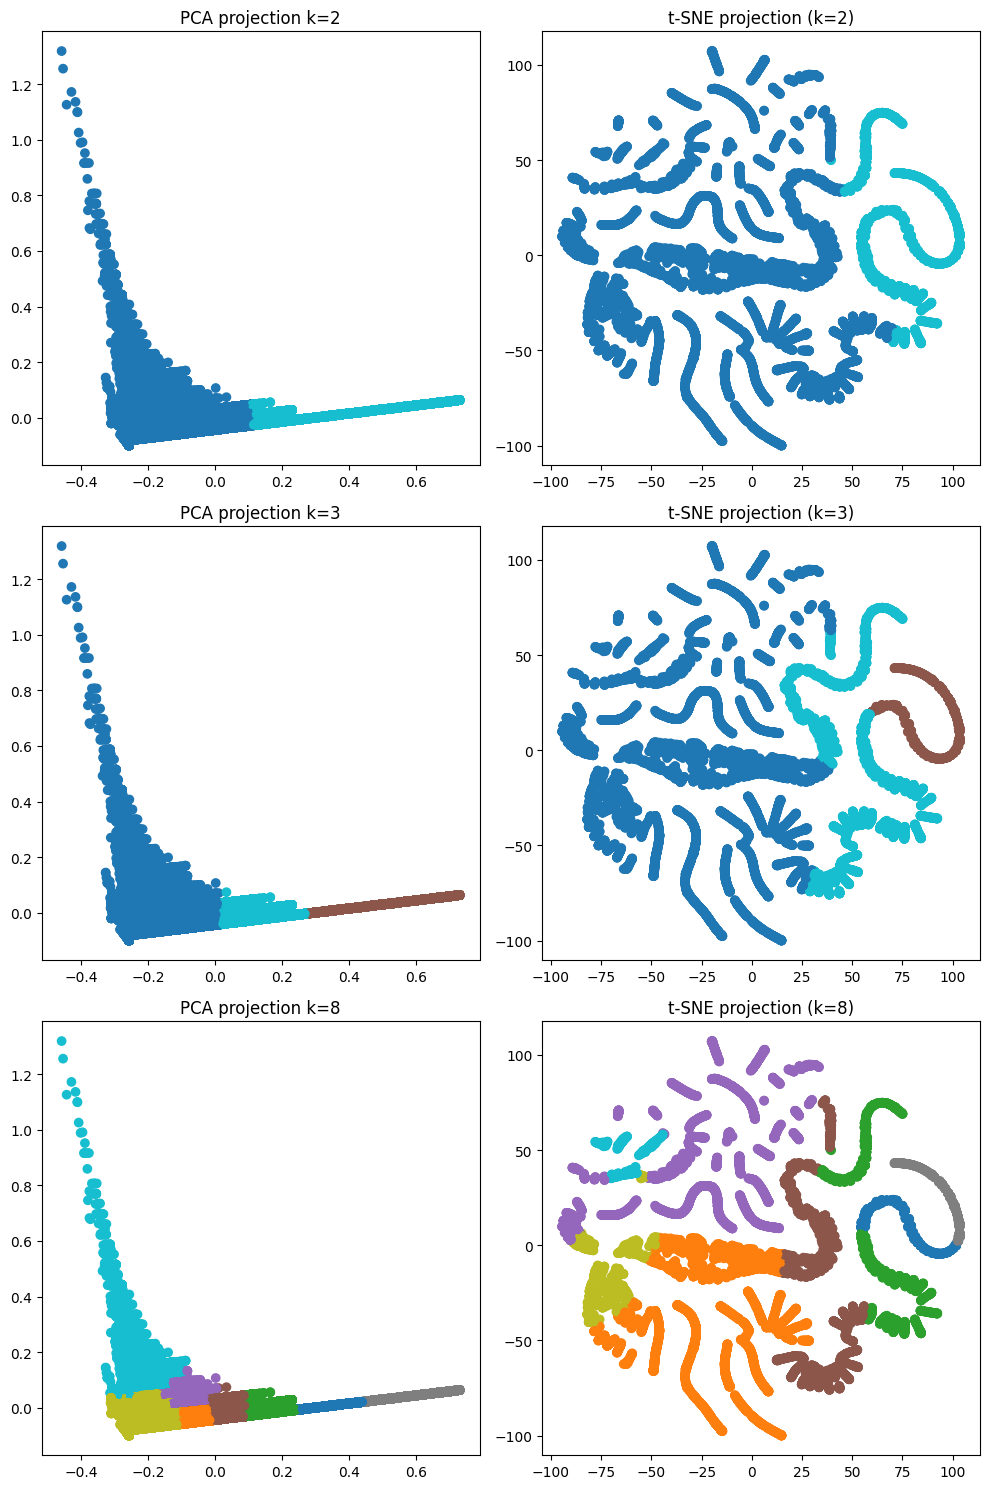

In [72]:
'''
Since Elbow Method & Silhouette Score suggest 2 cluster, 
but Calinski-Harabasz (CH) index suggest 8 cluster we should take help
of PCA or t-SNE projections to reveal whether 2 clusters or
8 clusters make more sense 
'''
#from sklearn.decomposition import PCA
#from sklearn.manifold import TSNE

fig, axes=plt.subplots(3,2,figsize=(10,15))
axes=axes.flatten()
#subset for tsne. since, dataset is big t-sne take huge time to execute
sampleIndex=np.random.choice(len(scaledData), size=10000, replace=False)
start=time.time()
for i,k in enumerate([2,3,8]):
    km=KMeans(n_clusters=k, random_state=42)
    labels=km.fit_predict(scaledData)
    
    #PCA
    pca=PCA(n_components=2)
    sel_feat_pca=pca.fit_transform(scaledData)
    axes[2*i].scatter(x=sel_feat_pca[:,0],
                y=sel_feat_pca[:,1],
                c=labels,
                cmap='tab10')
    axes[2*i].set_title(f"PCA projection k={k}")

    #t-SNE
    tsne=TSNE(n_components=2, random_state=42, perplexity=30)
    sel_feat_tsne=tsne.fit_transform(scaledData.iloc[sampleIndex])
    axes[2*i+1].scatter(x=sel_feat_tsne[:,0],
                y=sel_feat_tsne[:,1],
                c=labels[sampleIndex],
                cmap='tab10')
    axes[2*i+1].set_title(f"t-SNE projection (k={k})")

end=time.time()
print(f"Execution time = {end-start} sec")
plt.tight_layout()
plt.show()

**Segment into two clusters by KMeans**

In [73]:
km2=KMeans(n_clusters=2, random_state=42)
labels=km2.fit_predict(scaledData)

In [74]:
scaledData['Label']=labels

In [75]:
scaledData['Label'].value_counts()

Label
0    462821
1     91724
Name: count, dtype: int64

In [76]:
scaledData.groupby('Label').mean()

,visitCount,gapVisit(median),NumberOfPurchaseDay,NumberOfPurchaseDay/PurchasableDay
Label,,,,
0,0.034501,0.214239,0.059219,0.027473
1,0.005831,0.546770,0.031320,0.012352


In [77]:
scaledData.groupby('Label').median()

,visitCount,gapVisit(median),NumberOfPurchaseDay,NumberOfPurchaseDay/PurchasableDay
Label,,,,
0,0.026316,0.203333,0.051282,0.026027
1,0.000000,0.480000,0.025641,0.011760


'class 0' is better than 'class 1'.

In [78]:
readyToCluster['1stLabel']=scaledData['Label']

<Axes: xlabel='gapVisit(median)', ylabel='NumberOfPurchaseDay'>

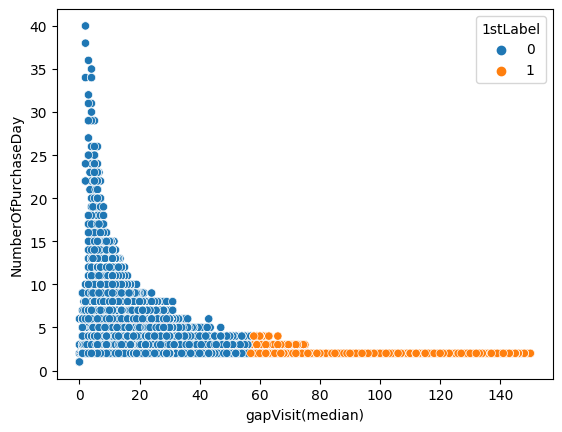

In [79]:
sns.scatterplot(data=readyToCluster,
               x=readyToCluster['gapVisit(median)'],
               y=readyToCluster['NumberOfPurchaseDay'],
               hue=readyToCluster['1stLabel'])

# Segment Again

***After labeling, we see that 'class 0' is better than 'class 1'. But, the member of 'class 0' is huge yet. So, we will segment cluster again of 'class 0' data.***

In [80]:
#filter
scaledData=scaledData[scaledData['Label']==0]

In [81]:
scaledData.head()

,visitCount,gapVisit(median),NumberOfPurchaseDay,NumberOfPurchaseDay/PurchasableDay,Label
MAGIC_KEY,,,,,
2CC2011C2DF,1.000000,0.013333,1.000000,0.276869,0
28D251217BD,0.947368,0.013333,0.948718,0.391779,0
2BFCB915234,0.894737,0.020000,0.897436,0.239830,0
29D9005EBAD,0.868421,0.026667,0.871795,0.232982,0
29F30296E7B,0.842105,0.013333,0.846154,0.583430,0


In [82]:
scaledData=scaledData.drop('Label', axis=1)
scaledData.head()

,visitCount,gapVisit(median),NumberOfPurchaseDay,NumberOfPurchaseDay/PurchasableDay
MAGIC_KEY,,,,
2CC2011C2DF,1.000000,0.013333,1.000000,0.276869
28D251217BD,0.947368,0.013333,0.948718,0.391779
2BFCB915234,0.894737,0.020000,0.897436,0.239830
29D9005EBAD,0.868421,0.026667,0.871795,0.232982
29F30296E7B,0.842105,0.013333,0.846154,0.583430


**Elbow Method**

Text(0, 0.5, 'Value of Inertia')

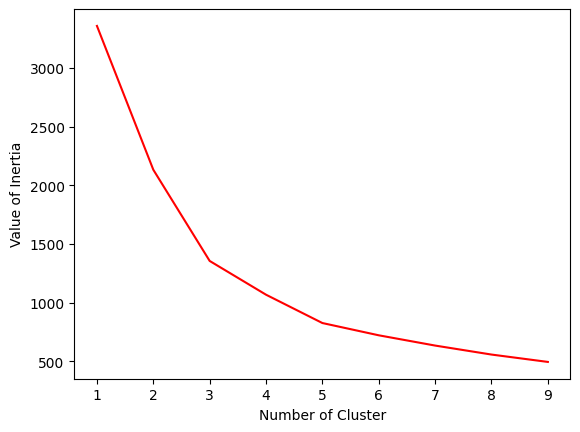

In [83]:
#find Inertia
#Inertia means sum of squared distances of samples to their closest cluster center
inertias=[]
for k in range(1,10):
    km=KMeans(n_clusters=k,random_state=42)
    km.fit_predict(scaledData)
    inertias.append(km.inertia_)

#plot Inertia
plt.plot(range(1,10),inertias,c='r')
plt.xlabel('Number of Cluster')
plt.ylabel('Value of Inertia')

**PCA & t-SNE**

Execution time = 89.91576933860779 sec


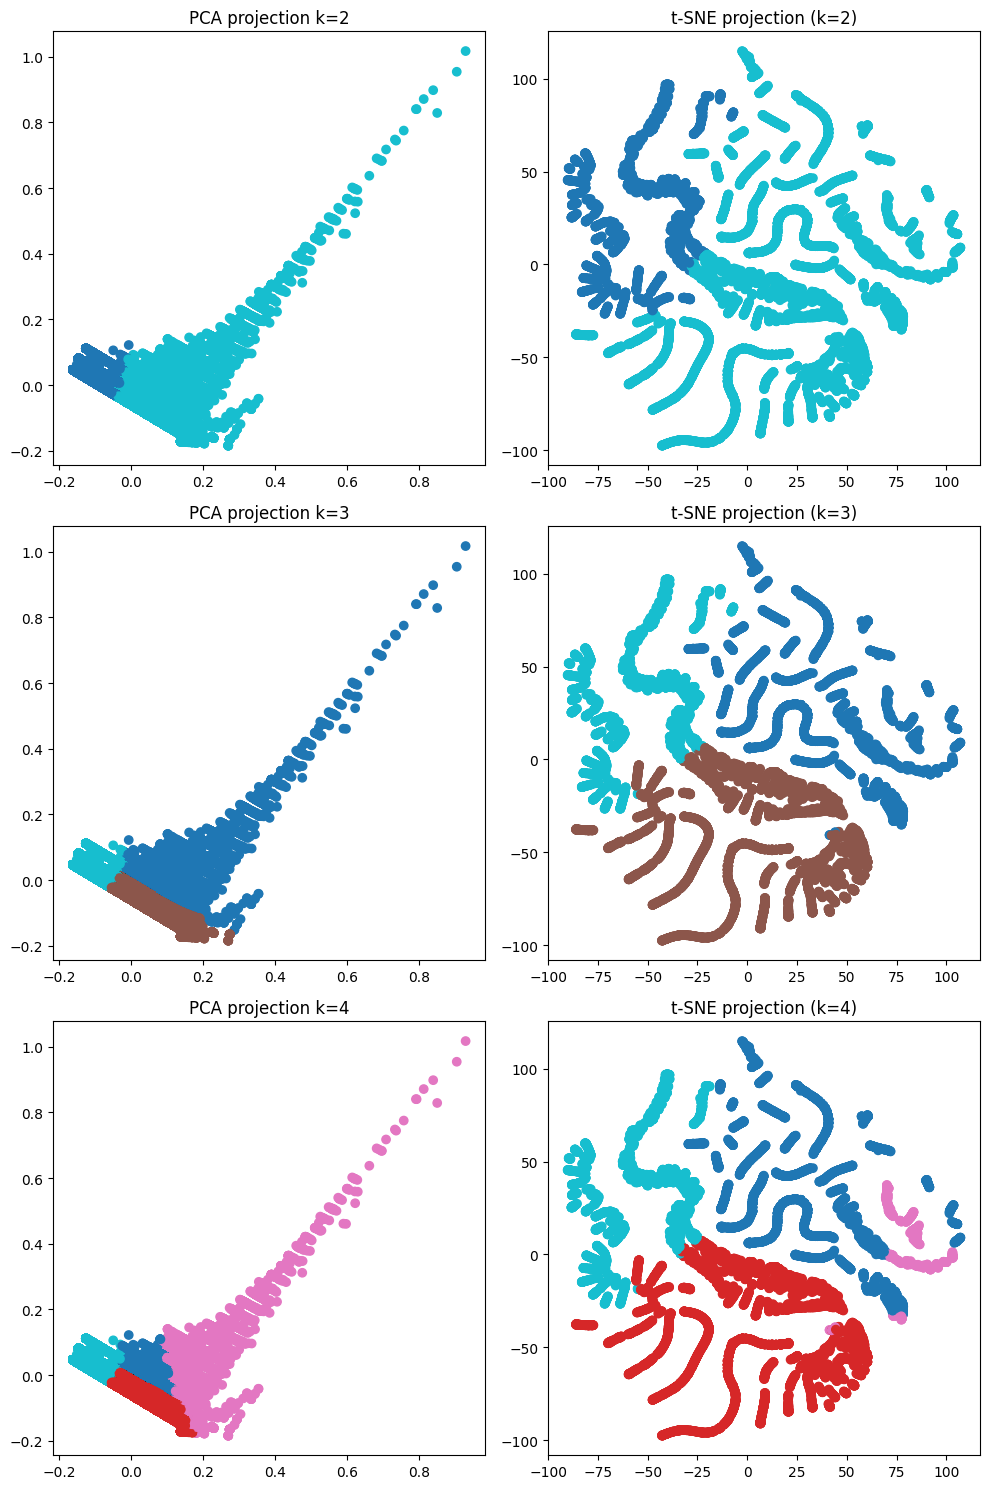

In [84]:
fig, axes=plt.subplots(3,2,figsize=(10,15))
axes=axes.flatten()
#subset for tsne. since, dataset is big t-sne take huge time to execute
sampleIndex=np.random.choice(len(scaledData), size=10000, replace=False)
start=time.time()
for i,k in enumerate([2,3,4]):
    km=KMeans(n_clusters=k, random_state=42)
    labels=km.fit_predict(scaledData)
    
    #PCA
    pca=PCA(n_components=2)
    sel_feat_pca=pca.fit_transform(scaledData)
    axes[2*i].scatter(x=sel_feat_pca[:,0],
                y=sel_feat_pca[:,1],
                c=labels,
                cmap='tab10')
    axes[2*i].set_title(f"PCA projection k={k}")

    #t-SNE
    tsne=TSNE(n_components=2, random_state=42, perplexity=30)
    sel_feat_tsne=tsne.fit_transform(scaledData.iloc[sampleIndex])
    axes[2*i+1].scatter(x=sel_feat_tsne[:,0],
                y=sel_feat_tsne[:,1],
                c=labels[sampleIndex],
                cmap='tab10')
    axes[2*i+1].set_title(f"t-SNE projection (k={k})")

end=time.time()
print(f"Execution time = {end-start} sec")
plt.tight_layout()
plt.show()

In [85]:
km3=KMeans(n_clusters=3, random_state=42)
label=km3.fit_predict(scaledData)

In [86]:
scaledData['Label']=label

In [87]:
scaledData['Label'].value_counts()

Label
1    194294
0    164091
2    104436
Name: count, dtype: int64

In [88]:
scaledData.groupby('Label').mean()

,visitCount,gapVisit(median),NumberOfPurchaseDay,NumberOfPurchaseDay/PurchasableDay
Label,,,,
0,0.076149,0.185238,0.099783,0.032334
1,0.008551,0.189790,0.033932,0.027866
2,0.017338,0.305288,0.042529,0.019104


'class 0' is best in this case

In [89]:
readyToCluster['2ndLabel']=scaledData['Label']

<Axes: xlabel='gapVisit(median)', ylabel='NumberOfPurchaseDay'>

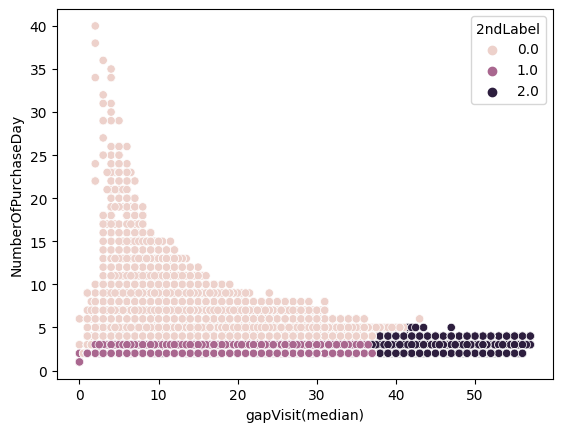

In [90]:
sns.scatterplot(data=readyToCluster,
               x=readyToCluster['gapVisit(median)'],
               y=readyToCluster['NumberOfPurchaseDay'],
               hue=readyToCluster['2ndLabel'])

# Segment Again

***After labeling, we found that 'class 0' is better than 'class 1'. However, the size of 'class 0' is still a bit large, so we will further segment the data within class 0.***

In [91]:
#filter
scaledData=scaledData[scaledData['Label']==0]

In [92]:
scaledData=scaledData.drop('Label', axis=1)

**Elbow Method**

Text(0, 0.5, 'Value of Inertia')

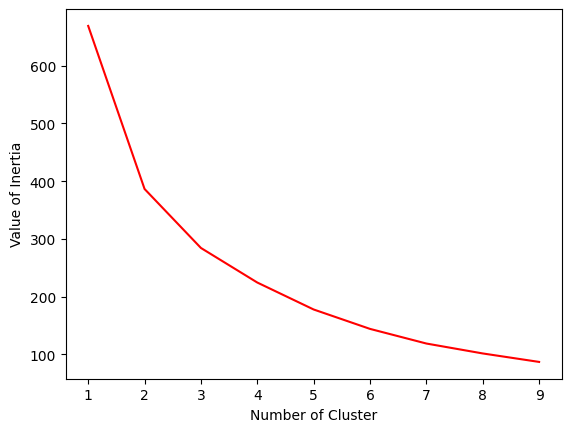

In [93]:
#find Inertia
#Inertia means sum of squared distances of samples to their closest cluster center
inertias=[]
for k in range(1,10):
    km=KMeans(n_clusters=k,random_state=42)
    km.fit_predict(scaledData)
    inertias.append(km.inertia_)

#plot Inertia
plt.plot(range(1,10),inertias,c='r')
plt.xlabel('Number of Cluster')
plt.ylabel('Value of Inertia')

**PCA & t-SNE**

Execution time = 53.329665422439575 sec


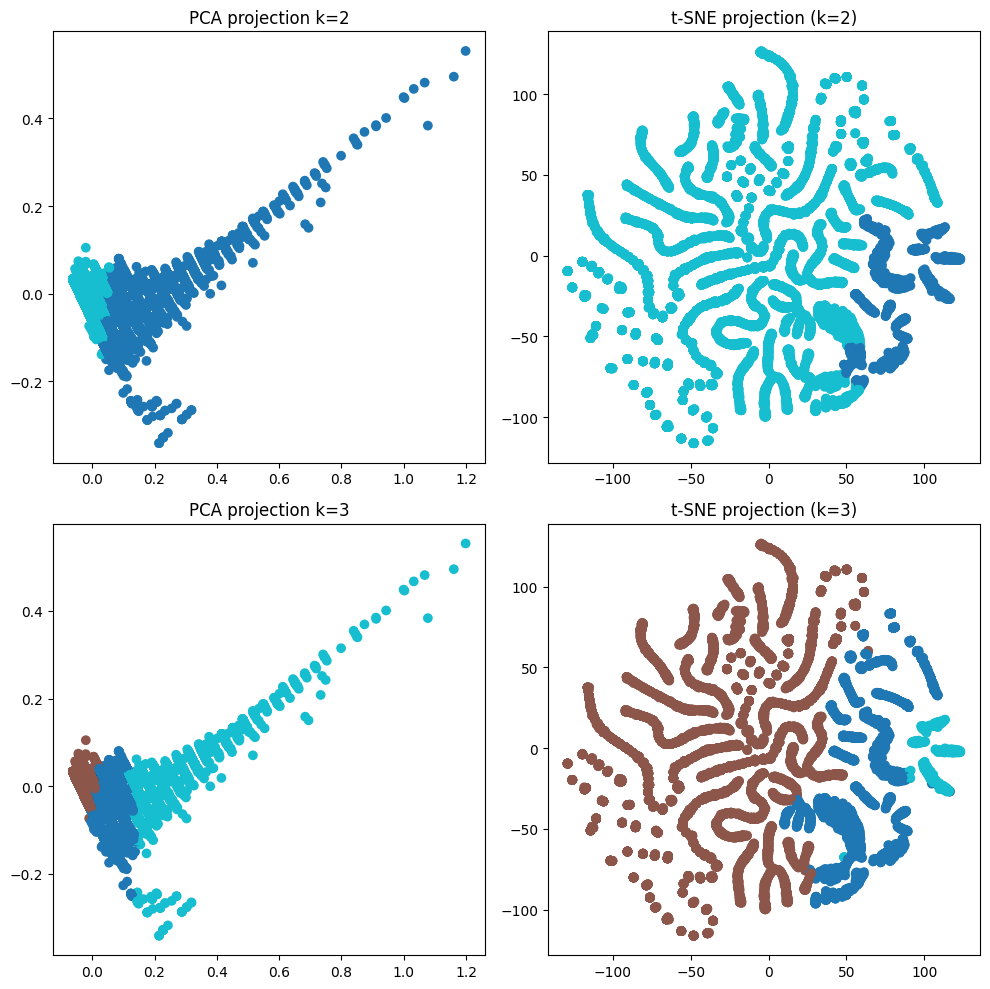

In [94]:
fig, axes=plt.subplots(2,2,figsize=(10,10))
axes=axes.flatten()
#subset for tsne. since, dataset is big t-sne take huge time to execute
sampleIndex=np.random.choice(len(scaledData), size=10000, replace=False)
start=time.time()
for i,k in enumerate([2,3]):
    km=KMeans(n_clusters=k, random_state=42)
    labels=km.fit_predict(scaledData)
    
    #PCA
    pca=PCA(n_components=2)
    sel_feat_pca=pca.fit_transform(scaledData)
    axes[2*i].scatter(x=sel_feat_pca[:,0],
                y=sel_feat_pca[:,1],
                c=labels,
                cmap='tab10')
    axes[2*i].set_title(f"PCA projection k={k}")

    #t-SNE
    tsne=TSNE(n_components=2, random_state=42, perplexity=30)
    sel_feat_tsne=tsne.fit_transform(scaledData.iloc[sampleIndex])
    axes[2*i+1].scatter(x=sel_feat_tsne[:,0],
                y=sel_feat_tsne[:,1],
                c=labels[sampleIndex],
                cmap='tab10')
    axes[2*i+1].set_title(f"t-SNE projection (k={k})")

end=time.time()
print(f"Execution time = {end-start} sec")
plt.tight_layout()
plt.show()

In [95]:
km=KMeans(n_clusters=2, random_state=42)
labels=km.fit_predict(scaledData)

In [96]:
scaledData['Label']=labels

In [97]:
scaledData['Label'].value_counts()

Label
1    144890
0     19201
Name: count, dtype: int64

In [98]:
scaledData.groupby('Label').mean()

,visitCount,gapVisit(median),NumberOfPurchaseDay,NumberOfPurchaseDay/PurchasableDay
Label,,,,
0,0.136498,0.111546,0.158387,0.054343
1,0.068152,0.195004,0.092017,0.029417


Here, 'class 0' is better than 'class 1'. But, the size of 'class 0' is very small. So, the 2ndLabel in readyToCluster is the final output.


In [99]:
readyToCluster['3rdLabel']=scaledData['Label']

<Axes: xlabel='gapVisit(median)', ylabel='NumberOfPurchaseDay'>

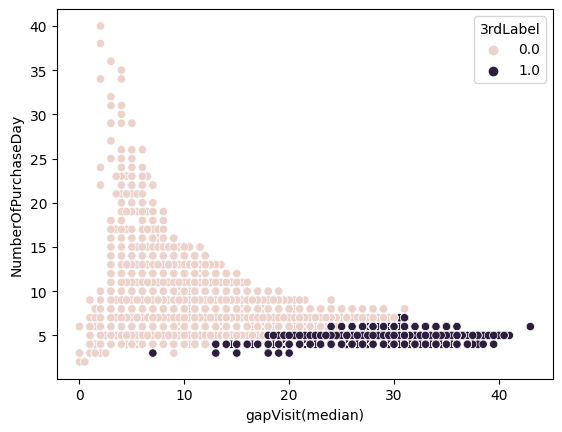

In [100]:
sns.scatterplot(data=readyToCluster,
               x=readyToCluster['gapVisit(median)'],
               y=readyToCluster['NumberOfPurchaseDay'],
               hue=readyToCluster['3rdLabel'])

In [101]:
print(readyToCluster['1stLabel'].value_counts())
print(readyToCluster['2ndLabel'].value_counts())
print(readyToCluster['3rdLabel'].value_counts())

1stLabel
0    462821
1     91724
Name: count, dtype: int64
2ndLabel
1.0    194294
0.0    164091
2.0    104436
Name: count, dtype: int64
3rdLabel
1.0    144890
0.0     19201
Name: count, dtype: int64


***After analysis sales data, we had got around 150,000 returning customers will make purchases within the first 15 days of the next month based on previous sales trend. The size of '2ndLabel' in 'readyToCluster' is the nearest with our analysis. So, we can conclude that, 'class 0' of '2ndLabel' is those customers who will purchase within the first 15 days of the next month.***

In [102]:
problem1=pd.read_csv('/kaggle/input/robi-datathon-30-qualifier-problem-1/problem 1.csv')

In [103]:
problem1.head()

,MAGIC_KEY
0,28D5BB06356
1,293BEAB4E98
2,2962EE8065C
3,2957BE29EA9
4,28E351A0745


In [104]:
problem1.duplicated().sum()

0

In [105]:
submissionP1_1=pd.merge(problem1, readyToCluster, on='MAGIC_KEY', how='left')[['MAGIC_KEY','2ndLabel']]

In [106]:
def PURCHASE(val):
    if(val==0):
        return 'Y'
    else:
        return 'N'

submissionP1_1['PURCHASE']=submissionP1_1['2ndLabel'].apply(PURCHASE)

In [107]:
submissionP1_1.drop('2ndLabel', axis=1, inplace=True)

In [108]:
submissionP1_1.head()

,MAGIC_KEY,PURCHASE
0,28D5BB06356,N
1,293BEAB4E98,Y
2,2962EE8065C,N
3,2957BE29EA9,N
4,28E351A0745,Y


In [109]:
submissionP1_1['PURCHASE'].value_counts()

PURCHASE
N    30271
Y    28418
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x7cb7da54d7e0>,
 [Text(-0.0545321708583203, 1.0986474604446501, 'N'),
  Text(0.05453206799552086, -1.0986474655503156, 'Y')],
 [Text(-0.029744820468174706, 0.5992622511516273, '51.6%'),
  Text(0.02974476436119319, -0.5992622539365358, '48.4%')])

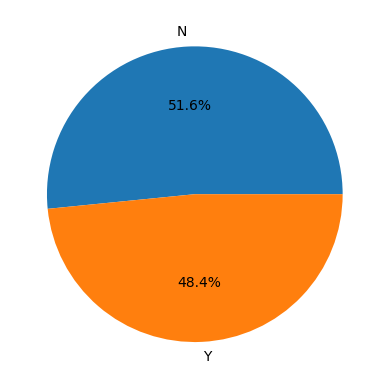

In [110]:
valueCount=submissionP1_1['PURCHASE'].value_counts()
plt.pie(valueCount.values, labels=valueCount.index, autopct='%1.1f%%')

In [111]:
submissionP1_1.to_csv('SubmissionP1_1.csv',index=False)

In [112]:
!pip freeze > requirements.txt